In [47]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv("/content/Social_Network_Ads.csv")

In [49]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [50]:
df = df.drop(columns = ['User ID','Gender'])

In [51]:
X = df.drop(columns = ['Purchased'])
y = df['Purchased']

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
sc = StandardScaler()

In [56]:
X_train_mod = sc.fit_transform(X_train)
X_test_mod = sc.transform(X_test)

In [57]:
X_train_mod

array([[-1.06675246, -0.38634438],
       [ 0.79753468, -1.22993871],
       [ 0.11069205,  1.853544  ],
       [ 0.60129393, -0.90995465],
       [ 1.87685881, -1.28811763],
       [-0.57615058,  1.44629156],
       [ 0.3069328 , -0.53179168],
       [ 0.99377543,  0.10817643],
       [-1.16487283,  0.45724994],
       [-1.55735433,  0.31180264],
       [ 1.0918958 ,  0.45724994],
       [-0.18366908, -0.47361276],
       [ 0.20881242, -0.32816546],
       [ 0.3069328 ,  0.28271318],
       [-1.16487283, -1.57901222],
       [ 0.11069205,  0.25362372],
       [ 2.07309956,  1.73718616],
       [ 0.40505317, -0.18271817],
       [ 1.4843773 ,  2.11534913],
       [-0.37990983,  1.21357589],
       [ 1.87685881,  1.50447048],
       [ 0.11069205,  0.02090805],
       [ 0.89565505, -1.31720709],
       [-1.36111358, -1.49174384],
       [-0.18366908, -0.5899706 ],
       [-0.57615058,  2.31897535],
       [ 0.99377543, -1.20084925],
       [-0.77239133,  1.06812859],
       [ 2.17121993,

In [58]:
model = Sequential()

In [59]:
model.add(Dense(10,input_dim = 2,activation = 'relu'))
model.add(Dense(10,activation = 'relu'))
model.add(Dense(5,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201 (804.00 B)

 Trainable params: 201 (804.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics = ['accuracy'])

In [63]:
#SGD
history_SGD = model.fit(X_train_mod,y_train,epochs = 100,batch_size = 1,validation_data = (X_test_mod,y_test))

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9250 - loss: 0.2135 - val_accuracy: 0.9375 - val_loss: 0.1961
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2168 - val_accuracy: 0.9375 - val_loss: 0.1993
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9156 - loss: 0.2176 - val_accuracy: 0.9375 - val_loss: 0.1998
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2145 - val_accuracy: 0.9375 - val_loss: 0.2008
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2170 - val_accuracy: 0.9375 - val_loss: 0.2064
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2146 - val_accuracy: 0.9375 - val_loss: 0.2021
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9250 - loss: 0.2116 - val_accuracy: 0.9375 - val_loss: 0.2072
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2162 - val_accu

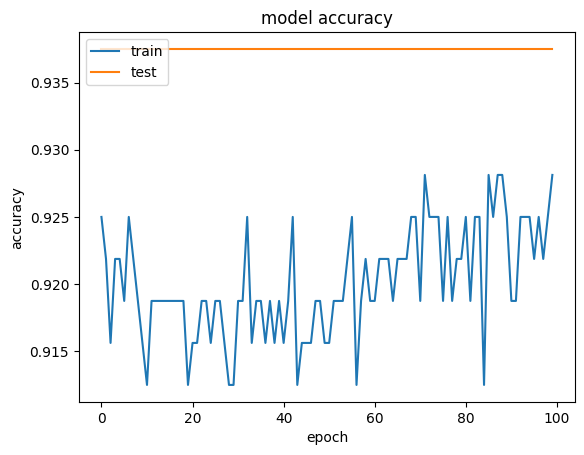

In [70]:
plt.plot(history_SGD.history['accuracy'])
plt.plot(history_SGD.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

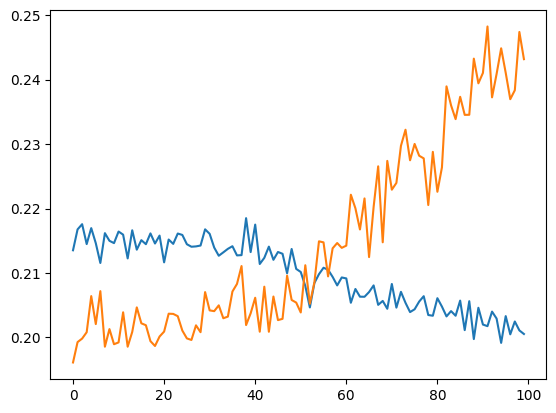

In [72]:
plt.plot(history_SGD.history['loss'])
plt.plot(history_SGD.history['val_loss'])
plt.show()

In [77]:
#Batch_GD
history_BGD = model.fit(X_train_mod,y_train,epochs = 400,batch_size = X_train.shape[0],validation_data = (X_test_mod,y_test))

Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9312 - loss: 0.1918 - val_accuracy: 0.9375 - val_loss: 0.2463
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9312 - loss: 0.1918 - val_accuracy: 0.9375 - val_loss: 0.2463
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9312 - loss: 0.1918 - val_accuracy: 0.9375 - val_loss: 0.2463
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9312 - loss: 0.1918 - val_accuracy: 0.9375 - val_loss: 0.2463
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9312 - loss: 0.1918 - val_accuracy: 0.9375 - val_loss: 0.2463
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9312 - loss: 0.1917 - val_accuracy: 0.9375 - val_loss: 0.2463
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9312 - loss: 0.1917 - val_accuracy: 0.9375 - val_loss: 0.2463
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9312 - loss: 0.1917 - val_accuracy: 0.9375 - val_l

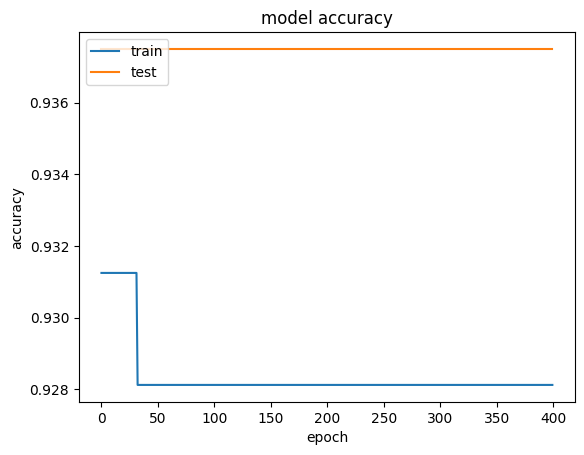

In [78]:
plt.plot(history_BGD.history['accuracy'])
plt.plot(history_BGD.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

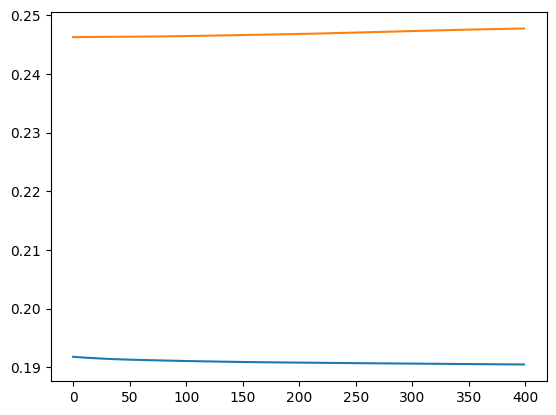

In [79]:
plt.plot(history_BGD.history['loss'])
plt.plot(history_BGD.history['val_loss'])
plt.show()